In [1]:
import pandas as pd
import csv
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
ratings = pd.read_csv("clean_quynh/cleaned_reviews_data.csv")
users = pd.read_csv("clean_quynh/cleaned_users_data.csv")
books = pd.read_csv("clean_quynh/cleaned_books_data.csv")


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24468\886829554.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  ratings = pd.read_csv("clean_quynh/cleaned_reviews_data.csv")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24468\886829554.py:3: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("clean_quynh/cleaned_books_data.csv")


In [3]:
ratings.head(5)

,isbn,isbn13,user_id,rating_score
0,0345465296,9780345465290.0,1742824,5.0
1,0345465296,9780345465290.0,9180313,5.0
2,0345465296,9780345465290.0,36153170,5.0
3,0345465296,9780345465290.0,22819383,4.0
4,0345465296,9780345465290.0,8845508,5.0


In [4]:
rating_count = ratings['rating_score'].value_counts()
rating_count

rating_score
4.0    298465
5.0    267569
3.0    185313
2.0     42409
1.0     27918
0.0     24183
Name: count, dtype: int64

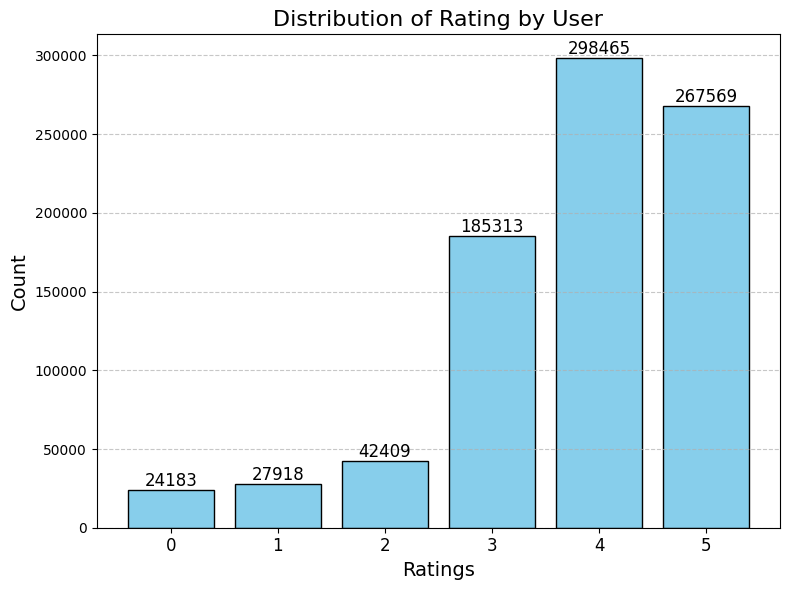

In [5]:
plt.figure(figsize=(8, 6))
bars = plt.bar(rating_count.index, rating_count.values, color='skyblue', edgecolor='black')

# Thêm số trên cột
for bar in bars:
    yval = bar.get_height()  # Lấy chiều cao của cột
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.1, int(yval), ha='center', va='bottom', fontsize=12)

# Cài đặt giao diện biểu đồ
plt.title('Distribution of Rating by User', fontsize=16)
plt.xlabel('Ratings', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rating_count.index, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

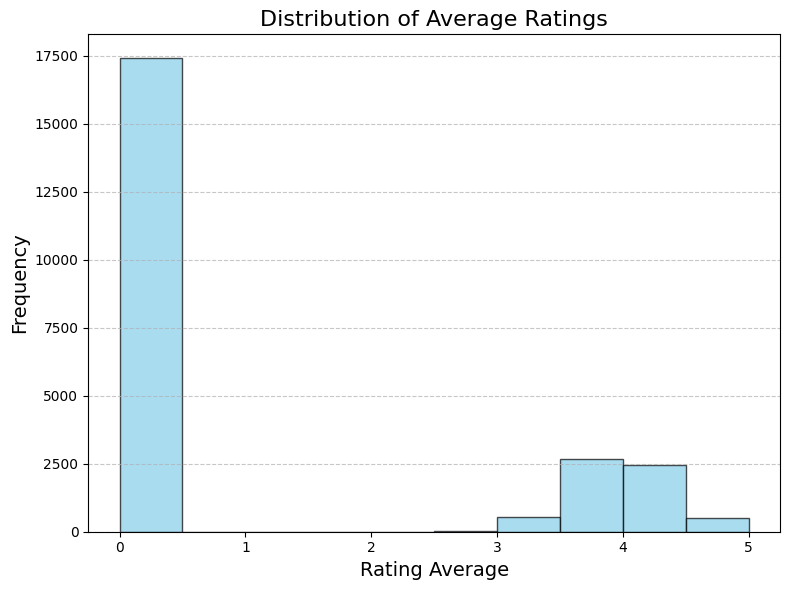

In [6]:
plt.figure(figsize=(8, 6))
plt.hist(users['avg_rating'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Average Ratings', fontsize=16)
plt.xlabel('Rating Average', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

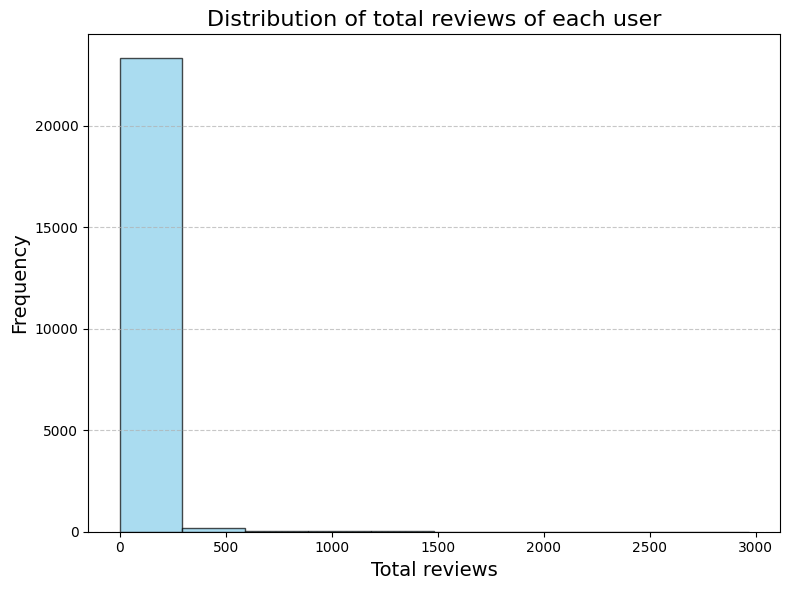

In [7]:
plt.figure(figsize=(8, 6))
plt.hist(users['total_reviews'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of total reviews of each user', fontsize=16)
plt.xlabel('Total reviews', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

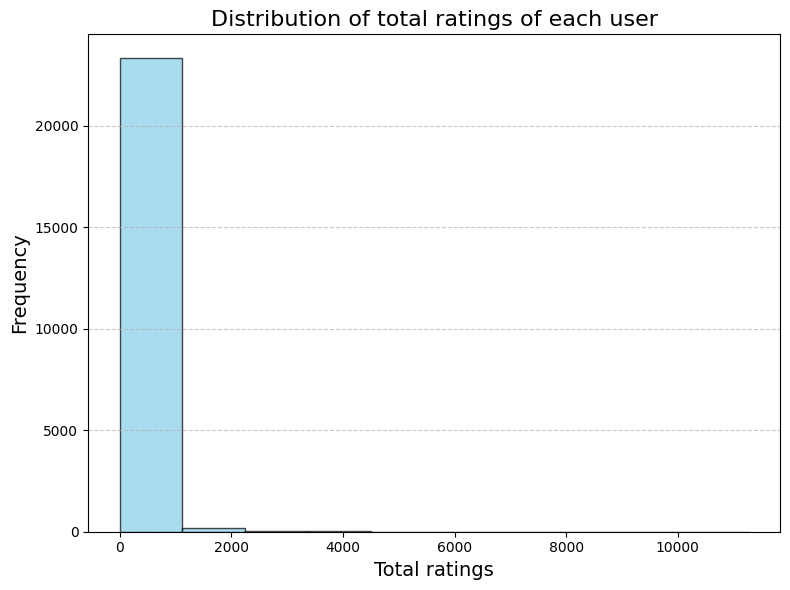

In [8]:
plt.figure(figsize=(8, 6))
plt.hist(users['total_ratings'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of total ratings of each user', fontsize=16)
plt.xlabel('Total ratings', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Book

In [9]:
language_counts = books['language'].value_counts()
print(language_counts)

language_counts.index = language_counts.index.str.strip("' ")


language
'English'                                  71218
'Spanish; Castilian'                        2338
'French'                                    1287
'German'                                     878
'Italian'                                    583
'Thai'                                       393
'Greek, Modern (1453-)'                      127
'Persian'                                    125
'Japanese'                                    80
'Russian'                                     77
'Portuguese'                                  61
'Dutch; Flemish'                              55
'Arabic'                                      41
'Multiple languages'                          40
'Swedish'                                     34
'Norwegian'                                   29
'Turkish'                                     20
'Ukrainian'                                   18
'Polish'                                      18
'Finnish'                                     17
'Latin'    

In [16]:
# Top 5 languages used most
books['language'].value_counts().head(5)

language
'English'               71218
'Spanish; Castilian'     2338
'French'                 1287
'German'                  878
'Italian'                 583
Name: count, dtype: int64

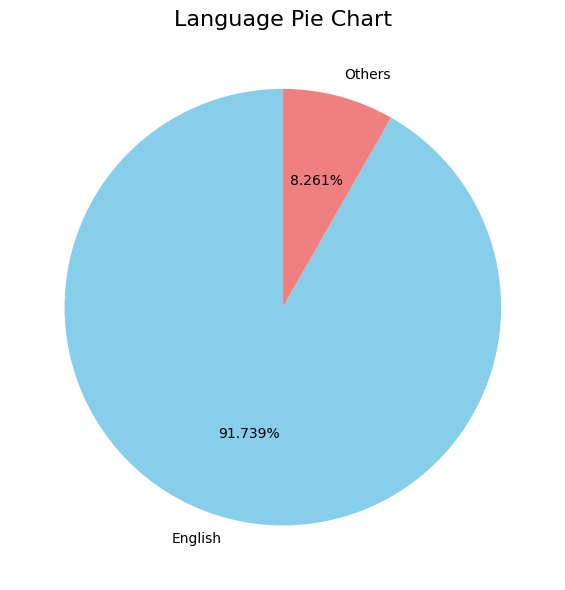

In [17]:
grouped_counts = pd.Series({
    'English': language_counts.get('English', 0),
    'Others': language_counts.sum() - language_counts.get('English', 0) 
})

# Vẽ biểu đồ tròn
plt.figure(figsize=(6, 6))
grouped_counts.plot(kind='pie', autopct='%1.3f%%', startangle=90, colors=['skyblue', 'lightcoral'], labels=grouped_counts.index)
plt.title('Language Pie Chart', fontsize=16)
plt.ylabel('')  # Xóa nhãn trục y
plt.tight_layout()
plt.show()

In [11]:
author_count = defaultdict(int)
for author in books['author']:
    author_count[author] += 1

# Sắp xếp tác giả theo count giảm dần
author_count = sorted(author_count.items(), key=lambda x: x[1], reverse=True)


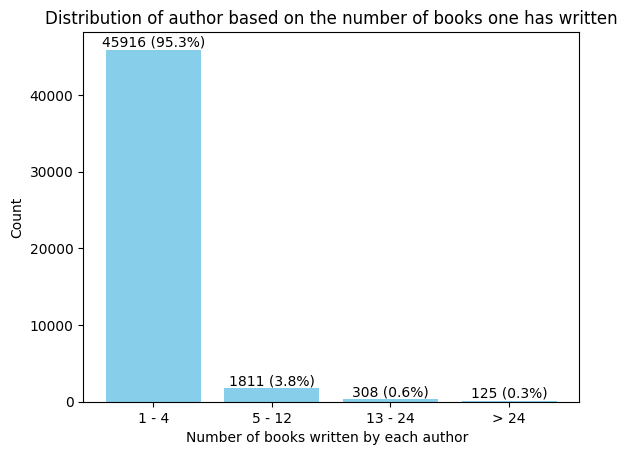

In [134]:
cnt_au_1 = 0
cnt_au_2 = 0
cnt_au_3 = 0
cnt_au_4 = 0

a1 = 5
a2 = 12
a3 = 24

for author, count in author_count:
    if count < a1:
        cnt_au_1 += 1
    elif a1 <= count <= a2:
        cnt_au_2  += 1
    elif a2 < count <= a3:
        cnt_au_3  += 1
    else:
        cnt_au_4  += 1
        
labels = [f'1 - {a1-1}', f'{a1} - {a2}', f'{a2+1} - {a3}', f'> {a3}']
sizes = [cnt_au_1 , cnt_au_2 , cnt_au_3 ,cnt_au_4]

total_authors = sum(sizes)
        
plt.bar(labels, sizes, color='skyblue')

# Thêm nhãn
plt.xlabel("Number of books written by each author  ")
plt.ylabel('Count')
plt.title('Distribution of author based on the number of books one has written')

for i, size in enumerate(sizes):
    percentage = (size / total_authors) * 100  # Tính phần trăm
    plt.text(i, size + 0.1, f'{size} ({percentage:.1f}%)', ha='center', va='bottom', fontsize=10)


# Hiển thị biểu đồ
plt.show()

In [14]:
books.head(1)

,isbn,isbn13,title,image_url,description,author,num_pages,language,review_count,kindle_price,publish_date,crawl_source,average_rating,series
0,'1662528396','9781662528392','Cruel Winter with You','https://images-na.ssl-images-amazon.com/image...,"'For two former childhood friends, a blustery ...",'Ali Hazelwood',73.0,'English',11514,'0.99',1.731398e+12,'https://www.goodreads.com/book/show/220389458...,3.71,Under The Mistletoe Collection


In [103]:
books['review_count'].describe()

count     78681.000000
mean       1019.018696
std        6325.393888
min           0.000000
25%           0.000000
50%           5.000000
75%          77.000000
max      301965.000000
Name: review_count, dtype: float64

0 - 5: 50%
6 - 20: 10%
20 - 90: 
90 - 200:
200 - 1000: 

In [106]:
book_1 = books[(books['review_count'] < 5)]
book_1['review_count'].describe()

count    38714.000000
mean         0.792117
std          1.178258
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          4.000000
Name: review_count, dtype: float64

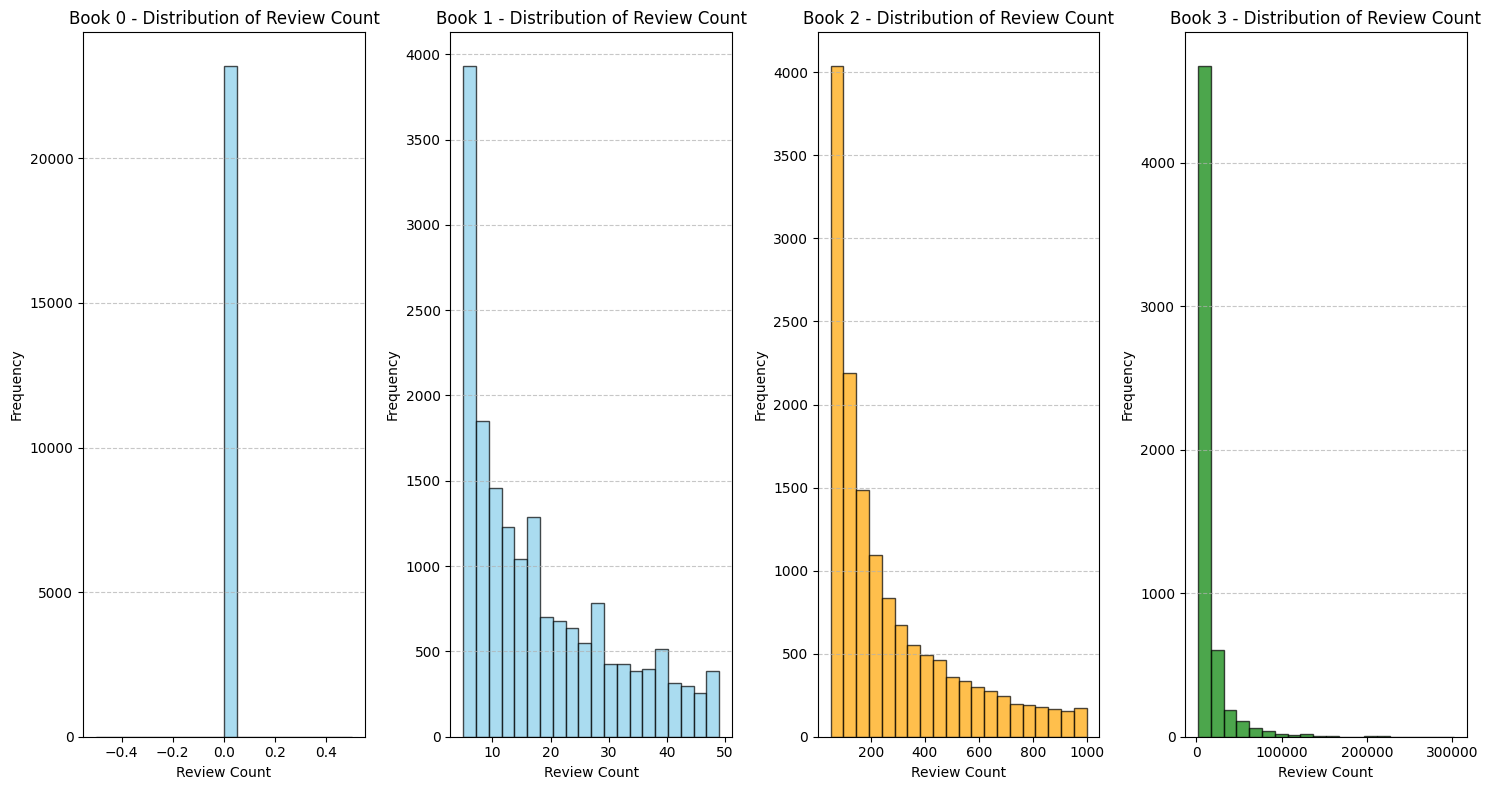

In [108]:
book_0 = books[(books['review_count'] == 0 )  ]
book_1 = books[(books['review_count'] > 4 ) & (books['review_count'] < 50)]
book_2 = books[(books['review_count'] > 50) & (books['review_count'] < 1000)]
book_3 = books[(books['review_count'] > 2000) ]
plt.figure(figsize=(15, 8))
# Subplot 1
plt.subplot(1, 4, 1)  # (rows, columns, index of the plot)
plt.hist(book_0['review_count'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Book 0 - Distribution of Review Count')
plt.xlabel('Review Count')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.subplot(1, 4, 2)  # (rows, columns, index of the plot)
plt.hist(book_1['review_count'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Book 1 - Distribution of Review Count')
plt.xlabel('Review Count')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2
plt.subplot(1, 4, 3)
plt.hist(book_2['review_count'], bins=20, color='orange', edgecolor='black', alpha=0.7)
plt.title('Book 2 - Distribution of Review Count')
plt.xlabel('Review Count')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 3
plt.subplot(1, 4, 4)
plt.hist(book_3['review_count'], bins=20, color='green', edgecolor='black', alpha=0.7)
plt.title('Book 3 - Distribution of Review Count')
plt.xlabel('Review Count')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Cải thiện bố cục và hiển thị biểu đồ
plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24468\3035070196.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bin_counts[i],  # Giá trị Y (số lượng)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24468\3035070196.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'{bin_counts[i]}',  # Thêm số liệu lên cột


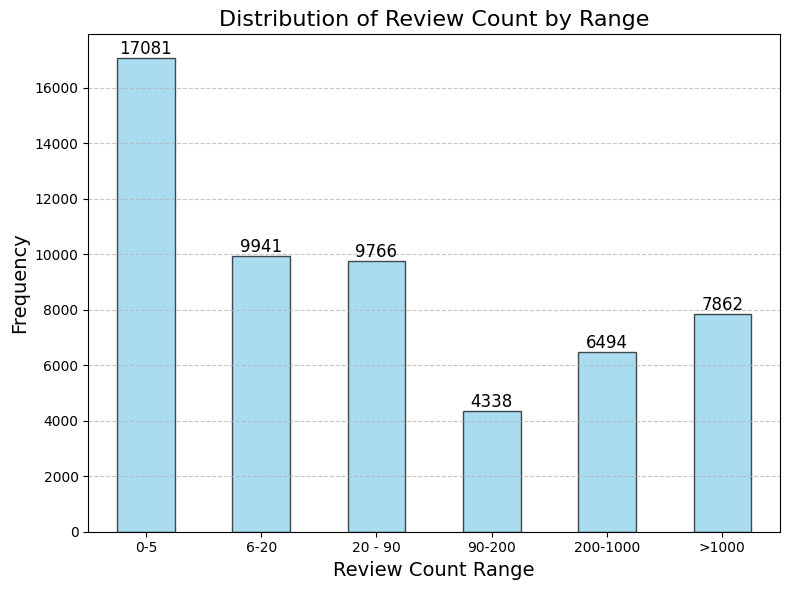

In [48]:
bins = [0, 5, 20, 90, 200, 1000, books['review_count'].max()]

# Đặt tên cho các nhóm
labels = ['0-5', '6-20', '20 - 90', '90-200', '200-1000', '>1000']

# Tạo cột mới với các khoảng đã chia
books['review_bins'] = pd.cut(books['review_count'], bins=bins, labels=labels, right=True)

# Đếm số lượng trong mỗi nhóm
bin_counts = books['review_bins'].value_counts().sort_index()

# Vẽ biểu đồ cột
plt.figure(figsize=(8, 6))
bin_counts.plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Review Count by Range', fontsize=16)
plt.xlabel('Review Count Range', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Thêm số liệu lên trên mỗi cột
for i in range(len(bin_counts)):
    plt.text(
        i,  # Vị trí X của cột
        bin_counts[i],  # Giá trị Y (số lượng)
        f'{bin_counts[i]}',  # Thêm số liệu lên cột
        ha='center',  # Căn giữa
        va='bottom',  # Căn dưới
        fontsize=12  # Kích thước font chữ
    )

plt.tight_layout()
plt.show()

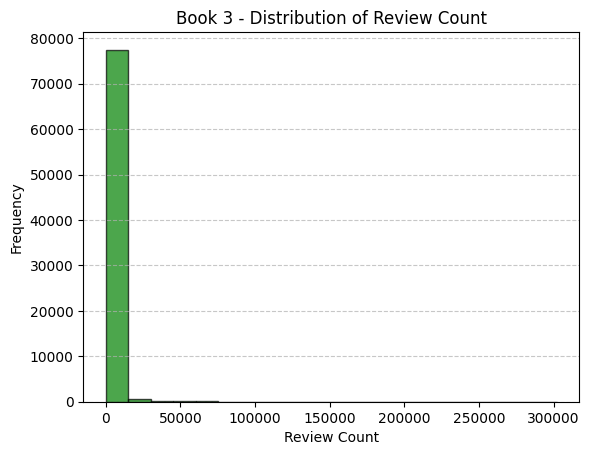

In [109]:
plt.hist(books['review_count'], bins=20, color='green', edgecolor='black', alpha=0.7)
plt.title('Book 3 - Distribution of Review Count')
plt.xlabel('Review Count')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [110]:
books.head(1)

,isbn,isbn13,title,image_url,description,author,num_pages,language,review_count,kindle_price,publish_date,crawl_source,average_rating,series,review_bins
0,'1662528396','9781662528392','Cruel Winter with You','https://images-na.ssl-images-amazon.com/image...,"'For two former childhood friends, a blustery ...",'Ali Hazelwood',73.0,'English',11514,'0.99',1.731398e+12,'https://www.goodreads.com/book/show/220389458...,3.71,Under The Mistletoe Collection,>1000


In [117]:
books['num_pages'].describe()

count     75796.000000
mean        280.213112
std        1425.251688
min           0.000000
25%         152.000000
50%         248.000000
75%         351.000000
max      380720.000000
Name: num_pages, dtype: float64

75% sách có số trang < 350 

In [126]:
book_pages = books[(books['num_pages'] < 351 )  ]

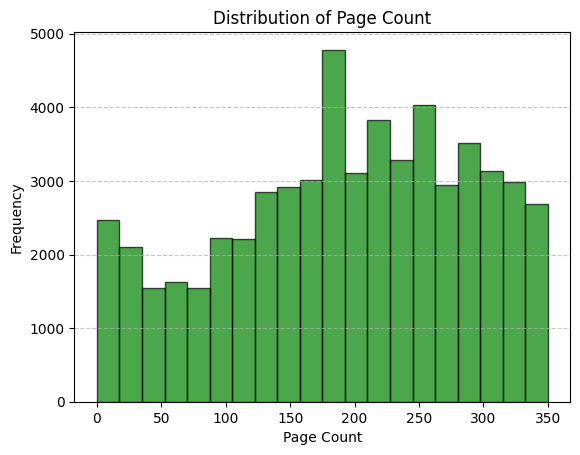

In [136]:
plt.hist(book_pages['num_pages'], bins=20, color='green', edgecolor='black', alpha=0.7)
plt.title('Distribution of Page Count')
plt.xlabel('Page Count')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

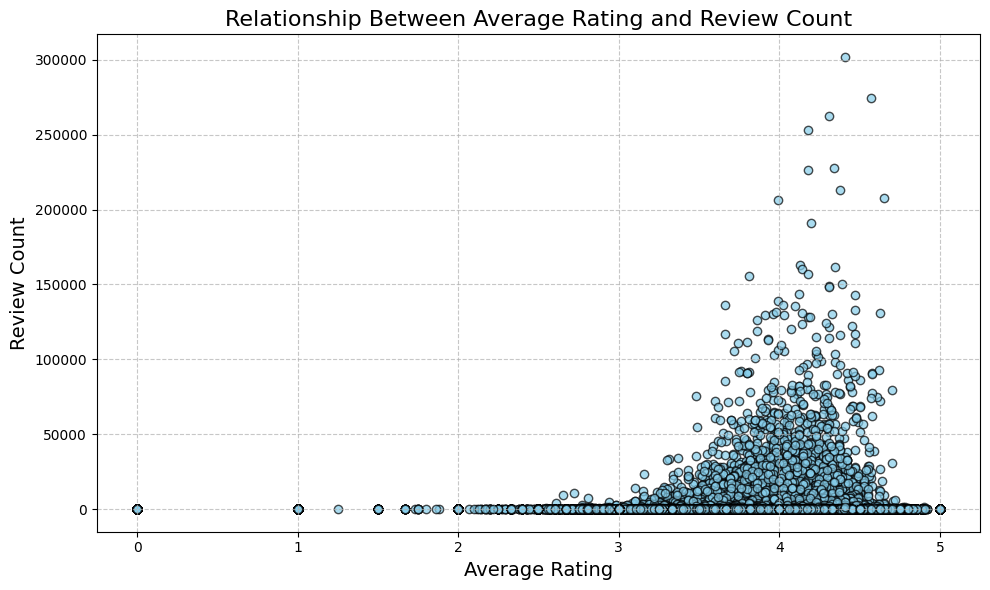

In [113]:
plt.figure(figsize=(10, 6))
plt.scatter(books['average_rating'], books['review_count'], color='skyblue', alpha=0.7, edgecolors='black')

plt.title('Relationship Between Average Rating and Review Count', fontsize=16)
plt.xlabel('Average Rating', fontsize=14)
plt.ylabel('Review Count', fontsize=14)

# Thêm lưới
plt.grid(True, linestyle='--', alpha=0.7)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

Sách nhiều review thì có khả năng cao là average rating cũng cao